<a href="https://colab.research.google.com/github/iamfaham/nyc-traffic-accident-gnn/blob/main/notebooks/nyc_traffic_accident_prediction_other_architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install all dependencies for the project
!pip install -q osmnx geopandas networkx torch torch-geometric folium sodapy pandas numpy matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sodapy import Socrata
import warnings
warnings.filterwarnings('ignore')

# Torch imports
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully")


All libraries imported successfully


In [3]:
# Connect to NYC Open Data API
client = Socrata("data.cityofnewyork.us", None)

# Download collision data (limit to 100K recent records for testing)
# Full dataset has 2M+ rows, so we start with a subset
print("Downloading NYC collision data from Open Data portal...")
results = client.get("h9gi-nx95", limit=100000, order="crash_date DESC")

# Convert to DataFrame
crashes_df = pd.DataFrame.from_records(results)

print(f"Downloaded {len(crashes_df):,} collision records")
print(f"Date range: {crashes_df['crash_date'].min()} to {crashes_df['crash_date'].max()}")
crashes_df.head()


Downloaded 100,000 collision records
Date range: 2024-09-02T00:00:00.000 to 2025-10-28T00:00:00.000


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,collision_id,vehicle_type_code1,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2025-10-28T00:00:00.000,15:31,MANHATTAN,10001,40.75206,-74.000984,"{'latitude': '40.75206', 'longitude': '-74.000...",W 30 ST,10 AVE,0,...,4853334,Station Wagon/Sport Utility Vehicle,Pick-up Truck,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-28T00:00:00.000,10:58,NaN,NaN,40.70165,-73.99149,"{'latitude': '40.70165', 'longitude': '-73.991...",BROOKLYN QUEENS EXPRESSWAY,NaN,0,...,4853293,Box Truck,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-10-28T00:00:00.000,21:53,NaN,NaN,40.85638,-73.82631,"{'latitude': '40.85638', 'longitude': '-73.826...",BRUCKNER EXPRESSWAY,NaN,2,...,4853450,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-10-28T00:00:00.000,23:44,BROOKLYN,11207,40.68556,-73.90718,"{'latitude': '40.68556', 'longitude': '-73.907...",CHAUNCEY ST,EVERGREEN AVE,0,...,4853373,Station Wagon/Sport Utility Vehicle,Box Truck,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-10-28T00:00:00.000,11:21,BRONX,10472,40.832718,-73.86289,"{'latitude': '40.832718', 'longitude': '-73.86...",NaN,NaN,1,...,4853312,Sedan,NaN,1866 WESTCHESTER AVE,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clean and prepare collision data
print("Cleaning collision data...")

# Convert datetime columns
crashes_df['crash_date'] = pd.to_datetime(crashes_df['crash_date'])
crashes_df['crash_time'] = pd.to_datetime(crashes_df['crash_time'], format='%H:%M').dt.time

# Create full timestamp
crashes_df['timestamp'] = pd.to_datetime(
    crashes_df['crash_date'].astype(str) + ' ' + crashes_df['crash_time'].astype(str)
)

# Filter rows with valid coordinates
crashes_df = crashes_df.dropna(subset=['latitude', 'longitude'])
crashes_df['latitude'] = crashes_df['latitude'].astype(float)
crashes_df['longitude'] = crashes_df['longitude'].astype(float)

# Filter to NYC bounds (removes outliers/errors)
nyc_bounds = {
    'lat_min': 40.4, 'lat_max': 40.95,
    'lon_min': -74.3, 'lon_max': -73.7
}
crashes_df = crashes_df[
    (crashes_df['latitude'] >= nyc_bounds['lat_min']) &
    (crashes_df['latitude'] <= nyc_bounds['lat_max']) &
    (crashes_df['longitude'] >= nyc_bounds['lon_min']) &
    (crashes_df['longitude'] <= nyc_bounds['lon_max'])
]

# Create injury severity binary target (1 if anyone injured/killed, 0 otherwise)
crashes_df['number_of_persons_injured'] = crashes_df['number_of_persons_injured'].fillna(0).astype(int)
crashes_df['number_of_persons_killed'] = crashes_df['number_of_persons_killed'].fillna(0).astype(int)
crashes_df['has_injury'] = ((crashes_df['number_of_persons_injured'] > 0) |
                             (crashes_df['number_of_persons_killed'] > 0)).astype(int)

# Extract temporal features
crashes_df['hour'] = crashes_df['timestamp'].dt.hour
crashes_df['day_of_week'] = crashes_df['timestamp'].dt.dayofweek
crashes_df['is_weekend'] = (crashes_df['day_of_week'] >= 5).astype(int)

print(f"Cleaned data: {len(crashes_df):,} valid records")
print(f"Injury rate: {crashes_df['has_injury'].mean()*100:.1f}%")
crashes_df[['timestamp', 'latitude', 'longitude', 'borough', 'has_injury', 'hour']].head()


Cleaning collision data...
Cleaned data: 95,011 valid records
Injury rate: 44.4%


,timestamp,latitude,longitude,borough,has_injury,hour
0,2025-10-28 15:31:00,40.752060,-74.000984,MANHATTAN,0,15
1,2025-10-28 10:58:00,40.701650,-73.991490,NaN,0,10
2,2025-10-28 21:53:00,40.856380,-73.826310,NaN,1,21
3,2025-10-28 23:44:00,40.685560,-73.907180,BROOKLYN,0,23
4,2025-10-28 11:21:00,40.832718,-73.862890,BRONX,1,11


(This may take 3-5 minutes for full NYC)
Downloaded street network:
  - Nodes (intersections): 4,618
  - Edges (road segments): 8,185


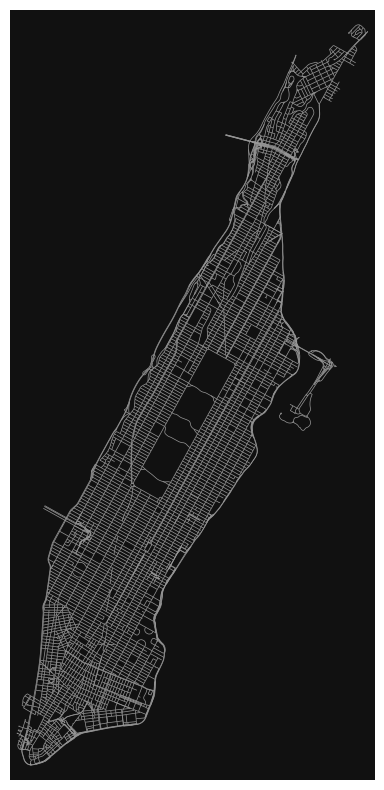

In [5]:
# Download NYC road network from OpenStreetMap
print("Downloading NYC street network from OpenStreetMap...")
print("(This may take 3-5 minutes for full NYC)")

# For faster testing, start with Manhattan only
# To use full NYC, change to: place_name = "New York City, New York, USA"
place_name = "Manhattan, New York City, New York, USA"

# Get drivable street network
G = ox.graph_from_place(
    place_name,
    network_type='drive',  # Only drivable roads
    simplify=True  # Consolidate intersections
)

# Convert to undirected for simplicity (can keep directed if needed)
G = G.to_undirected()

print(f"Downloaded street network:")
print(f"  - Nodes (intersections): {G.number_of_nodes():,}")
print(f"  - Edges (road segments): {G.number_of_edges():,}")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(10,10))


In [6]:
# ===== CELL 5: SPATIAL JOIN + NEGATIVE SAMPLING (COMPLETE) =====
print("="*80)
print("STEP 1: Spatial join and negative sample generation")
print("="*80)

# --- PART A: CREATE GEODA TAFRAME ---
print("\nCreating GeoDataFrame from crashes_df...")
crashes_gdf = gpd.GeoDataFrame(
    crashes_df,
    geometry=gpd.points_from_xy(crashes_df.longitude, crashes_df.latitude),
    crs="EPSG:4326"
)

# Add time_window
if 'time_window' not in crashes_gdf.columns:
    crashes_gdf['time_window'] = crashes_df['timestamp'].dt.floor('1H')

print(f"Created GeoDataFrame with {len(crashes_gdf):,} crashes")

# --- PART B: SPATIAL JOIN TO ROAD NETWORK ---
print("\n  Performing spatial join to road network...")

# Get nodes as GeoDataFrame
nodes_gdf = ox.graph_to_gdfs(G, edges=False).reset_index()

# Filter crashes to network bounds
crashes_gdf = crashes_gdf[crashes_gdf.within(nodes_gdf.unary_union.convex_hull)]
crashes_gdf = crashes_gdf.reset_index(drop=True)
print(f"Crashes within network bounds: {len(crashes_gdf):,}")

# Match CRS
crashes_gdf = crashes_gdf.to_crs(nodes_gdf.crs)

# Build spatial index with BallTree
from sklearn.neighbors import BallTree
node_list = list(G.nodes())
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
tree = BallTree(np.radians(node_coords), metric='haversine')

# Find nearest node for each crash
crash_coords = np.radians(crashes_gdf[['latitude', 'longitude']].values)
distances, indices = tree.query(crash_coords, k=1)
distances_m = distances[:, 0] * 6371000  # Convert to meters

# Filter: only crashes within 50m of a node
max_distance = 50
valid_mask = distances_m <= max_distance
crashes_gdf = crashes_gdf[valid_mask].copy().reset_index(drop=True)
valid_indices = indices[valid_mask, 0]

# Assign nearest_node
crashes_gdf['nearest_node'] = [node_list[i] for i in valid_indices]

print(f"Mapped {len(crashes_gdf):,} crashes to {crashes_gdf['nearest_node'].nunique()} nodes")
print(f"  Average distance: {distances_m[valid_mask].mean():.1f}m")

# --- PART C: NEGATIVE SAMPLING ---
print("\n" + "="*80)
print("STEP 2: Generating negative samples")
print("="*80)

# Get unique components
all_time_windows = sorted(crashes_gdf['time_window'].unique())
all_nodes = list(G.nodes())

print(f"Dataset dimensions:")
print(f"  - Time windows: {len(all_time_windows):,}")
print(f"  - Nodes: {len(all_nodes):,}")
print(f"  - Full combinations: {len(all_nodes) * len(all_time_windows):,}")

# Sample 20% of time windows for memory efficiency
import random
random.seed(42)
sample_rate = 0.2
sampled_times = random.sample(all_time_windows, k=int(len(all_time_windows) * sample_rate))
sampled_times = sorted(sampled_times)

print(f"\nSampling {sample_rate*100:.0f}% of time windows")
print(f"  - Sampled times: {len(sampled_times):,}")
print(f"  - Total combinations: {len(all_nodes) * len(sampled_times):,}")

# Create all node-time combinations
from itertools import product
all_combinations = list(product(all_nodes, sampled_times))
full_matrix = pd.DataFrame(all_combinations, columns=['node_id', 'time_window'])

# Aggregate actual crashes
print("\nAggregating crash records...")
crash_agg = crashes_gdf.groupby(['nearest_node', 'time_window']).agg({
    'collision_id': 'count',
    'has_injury': 'sum',
    'number_of_persons_injured': 'sum',
    'number_of_persons_killed': 'sum'
}).rename(columns={'collision_id': 'crash_count'}).reset_index()

# Merge to create complete dataset
complete_data = full_matrix.merge(
    crash_agg,
    left_on=['node_id', 'time_window'],
    right_on=['nearest_node', 'time_window'],
    how='left'
).drop('nearest_node', axis=1, errors='ignore')

# Fill NaN (negative samples)
complete_data['crash_count'] = complete_data['crash_count'].fillna(0).astype(int)
complete_data['has_injury'] = complete_data['has_injury'].fillna(0).astype(int)
complete_data['number_of_persons_injured'] = complete_data['number_of_persons_injured'].fillna(0).astype(int)
complete_data['number_of_persons_killed'] = complete_data['number_of_persons_killed'].fillna(0).astype(int)

# Create binary label
complete_data['has_crash'] = (complete_data['crash_count'] > 0).astype(int)

# Add temporal features
complete_data['hour'] = complete_data['time_window'].dt.hour
complete_data['day_of_week'] = complete_data['time_window'].dt.dayofweek
complete_data['is_weekend'] = (complete_data['day_of_week'] >= 5).astype(int)
complete_data['month'] = complete_data['time_window'].dt.month


STEP 1: Spatial join and negative sample generation

Creating GeoDataFrame from crashes_df...
Created GeoDataFrame with 95,011 crashes

  Performing spatial join to road network...
Crashes within network bounds: 19,217
Mapped 13,501 crashes to 3336 nodes
  Average distance: 10.6m

STEP 2: Generating negative samples
Dataset dimensions:
  - Time windows: 6,941
  - Nodes: 4,618
  - Full combinations: 32,053,538

Sampling 20% of time windows
  - Sampled times: 1,388
  - Total combinations: 6,409,784

Aggregating crash records...


In [7]:
# ADD THIS AFTER complete_data['month'] = complete_data['time_window'].dt.month

# ===== SOPHISTICATED FEATURE 1: RUSH HOUR INTENSITY =====
print("\n📊 Adding rush hour intensity feature...")

# Define rush hour periods with intensity scores
def get_rush_hour_intensity(hour):
    """
    Assign rush hour intensity based on traffic patterns
    0 = off-peak, 1-3 = varying intensity
    """
    # Morning rush (7-9 AM): intensity increases then decreases
    if hour == 7:
        return 2
    elif hour == 8:
        return 3  # Peak morning
    elif hour == 9:
        return 2
    # Evening rush (5-7 PM): intensity increases then decreases
    elif hour == 17:
        return 2
    elif hour == 18:
        return 3  # Peak evening
    elif hour == 19:
        return 2
    # Late night (11 PM - 3 AM): moderate risk due to fatigue/intoxication
    elif hour >= 23 or hour <= 3:
        return 1
    else:
        return 0  # Off-peak

complete_data['rush_hour_intensity'] = complete_data['hour'].apply(get_rush_hour_intensity)

print(f"✓ Rush hour intensity added (0-3 scale)")
print(f"  Peak hours (intensity=3): {(complete_data['rush_hour_intensity']==3).sum():,} samples")


# ADD THIS RIGHT AFTER RUSH HOUR INTENSITY

# ===== SOPHISTICATED FEATURE 4: HOLIDAY INDICATOR =====
print("\n📅 Adding holiday indicators...")

# Major US holidays (approximate - you can refine dates)
import datetime

def is_holiday(date):
    """Check if date is near a major holiday (±1 day)"""
    year = date.year
    month = date.month
    day = date.day

    # Major holidays
    holidays = [
        (1, 1),   # New Year
        (7, 4),   # July 4th
        (12, 25), # Christmas
        (11, 27), # Thanksgiving (approximate - 4th Thu of Nov)
        (12, 31), # New Year's Eve
    ]

    # Check if within 1 day of holiday
    for h_month, h_day in holidays:
        if month == h_month and abs(day - h_day) <= 1:
            return 1

    # Long weekends (Friday before/Monday after major holidays)
    if date.weekday() == 4 and (month, day+3) in holidays:  # Friday
        return 1
    if date.weekday() == 0 and (month, day-3) in holidays:  # Monday
        return 1

    return 0

complete_data['is_holiday'] = complete_data['time_window'].apply(is_holiday)

print(f"✓ Holiday indicator added")
print(f"  Holiday periods: {complete_data['is_holiday'].sum():,} samples ({complete_data['is_holiday'].mean()*100:.2f}%)")

# ADD THIS RIGHT AFTER HOLIDAY INDICATOR

# ===== SOPHISTICATED FEATURE 5: WEATHER/SEASON PROXY =====
print("\n🌦️  Adding weather/season proxy features...")

# Season indicators
complete_data['season'] = complete_data['month'].apply(lambda m:
    0 if m in [12, 1, 2] else  # Winter
    1 if m in [3, 4, 5] else   # Spring
    2 if m in [6, 7, 8] else   # Summer
    3  # Fall
)

# Weather risk proxy (based on season and time)
def weather_risk_proxy(row):
    """
    Estimate weather-related crash risk
    0 = low risk, 1-3 = increasing risk
    """
    season = row['season']
    hour = row['hour']

    # Winter: higher risk overall, especially morning/evening (ice)
    if season == 0:  # Winter
        if hour in [6, 7, 8, 17, 18, 19]:
            return 3  # Rush hour + winter = high risk
        else:
            return 2  # Winter baseline risk

    # Spring: moderate risk (rain)
    elif season == 1:
        if hour in [7, 8, 17, 18]:
            return 2
        else:
            return 1

    # Summer: lower risk except rush hour heat
    elif season == 2:
        if hour in [12, 13, 14, 15, 16]:  # Afternoon heat
            return 1
        else:
            return 0

    # Fall: moderate risk (leaves, early darkness)
    else:
        if hour >= 18 or hour <= 6:  # Darkness
            return 2
        else:
            return 1

complete_data['weather_risk'] = complete_data.apply(weather_risk_proxy, axis=1)

# Add darkness indicator (more precise than weather_risk)
def is_dark(row):
    """
    Check if it's dark (higher crash risk)
    Approximate sunrise/sunset times for NYC
    """
    month = row['month']
    hour = row['hour']

    # Winter: dark 5 PM - 7 AM
    if month in [11, 12, 1, 2]:
        return 1 if hour >= 17 or hour <= 7 else 0
    # Summer: dark 8 PM - 5 AM
    elif month in [5, 6, 7, 8]:
        return 1 if hour >= 20 or hour <= 5 else 0
    # Spring/Fall: dark 6 PM - 6 AM
    else:
        return 1 if hour >= 18 or hour <= 6 else 0

complete_data['is_dark'] = complete_data.apply(is_dark, axis=1)

print(f"Weather/season proxies added")
print(f"  High weather risk (3): {(complete_data['weather_risk']==3).sum():,} samples")
print(f"  Dark conditions: {complete_data['is_dark'].sum():,} samples ({complete_data['is_dark'].mean()*100:.1f}%)")




📊 Adding rush hour intensity feature...
✓ Rush hour intensity added (0-3 scale)
  Peak hours (intensity=3): 651,138 samples

📅 Adding holiday indicators...
✓ Holiday indicator added
  Holiday periods: 230,900 samples (3.60%)

🌦️  Adding weather/season proxy features...
Weather/season proxies added
  High weather risk (3): 387,912 samples
  Dark conditions: 2,890,868 samples (45.1%)


In [10]:
# Extract static features for each node from OSM
print("Extracting node features from road network...")

node_features = []
node_ids = []

for node, data in G.nodes(data=True):
    node_ids.append(node)

    # Get connected edges to determine node characteristics
    edges = G.edges(node, data=True)

    # Aggregate edge properties
    highway_types = [e[2].get('highway', 'unclassified') for e in edges]
    lanes = [int(e[2].get('lanes', 1)) if isinstance(e[2].get('lanes'), (int, str)) and str(e[2].get('lanes')).isdigit() else 1 for e in edges]
    speeds = []
    for e in edges:
        speed_val = e[2].get('maxspeed', 25)
        if isinstance(speed_val, str):
            # Try to clean and convert string speeds
            try:
                # Remove non-digit characters (like ' mph') and convert
                speed_val = int(''.join(filter(str.isdigit, speed_val)))
            except ValueError:
                speed_val = 25 # Default to 25 if conversion fails
        elif not isinstance(speed_val, (int, float)):
             speed_val = 25 # Default if not int, float or parsable string
        speeds.append(int(speed_val))

    # Node degree (connectivity)
    degree = G.degree(node)

    # Encode highway type (convert to numeric)
    highway_priority = {
        'motorway': 5, 'trunk': 4, 'primary': 3,
        'secondary': 2, 'tertiary': 1, 'residential': 0,
        'unclassified': 0
    }
    max_highway = max([highway_priority.get(h if isinstance(h, str) else h[0] if isinstance(h, list) else 'unclassified', 0)
                       for h in highway_types]) if highway_types else 0

    features = [
        degree,  # Node connectivity
        len(edges),  # Number of connected roads
        max_highway,  # Highest road class
        np.mean(lanes) if lanes else 1,  # Average lanes
        np.mean(speeds) if speeds else 25,  # Average speed limit
        data.get('x', 0),  # Longitude
        data.get('y', 0)   # Latitude
    ]

    node_features.append(features)

# Convert to DataFrame
node_features_df = pd.DataFrame(node_features, columns=[
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude'
])
node_features_df['node_id'] = node_ids

print(f"Extracted features for {len(node_features_df):,} nodes")
print(f"Feature dimensions: {node_features_df.shape[1]-1}")  # -1 for node_id
print(node_features_df.describe())

# ===== SOPHISTICATED FEATURE 2: INTERSECTION COMPLEXITY =====
print("\n🔀 Computing intersection complexity...")

# Calculate complexity score based on degree and road types
node_features_df['intersection_complexity'] = (
    node_features_df['degree'] * 0.5 +  # Number of connections
    node_features_df['highway_class'] * 0.3 +  # Road importance
    node_features_df['num_edges'] * 0.2  # Total edges
)

# Normalize to 0-10 scale
complexity_min = node_features_df['intersection_complexity'].min()
complexity_max = node_features_df['intersection_complexity'].max()
node_features_df['intersection_complexity'] = (
    (node_features_df['intersection_complexity'] - complexity_min) /
    (complexity_max - complexity_min) * 10
)

print(f"✓ Intersection complexity computed (0-10 scale)")
print(f"  High complexity (>7): {(node_features_df['intersection_complexity']>7).sum()} nodes")


# ===== SOPHISTICATED FEATURE 3: SPEED DIFFERENTIAL =====
print("\n⚡ Computing speed differential (risk factor)...")

# Speed differential = difference from typical speed (25 mph)
# Higher differential = higher risk (either too slow or too fast)
typical_speed = 25
node_features_df['speed_differential'] = np.abs(
    node_features_df['avg_speed'] - typical_speed
)

# Also create speed category
def categorize_speed(speed):
    if speed < 20:
        return 0  # Very slow (residential)
    elif speed <= 25:
        return 1  # Normal
    elif speed <= 35:
        return 2  # Fast (arterial)
    else:
        return 3  # Very fast (highway)

node_features_df['speed_category'] = node_features_df['avg_speed'].apply(categorize_speed)

print(f"✓ Speed features computed")
print(f"  High differential (>10 mph): {(node_features_df['speed_differential']>10).sum()} nodes")


print("\nExpanding features to all time windows...")
# Ensure node_time_data is the correct DataFrame before merging
# It should be the complete_data from the previous step
if 'node_time_data' not in locals() or node_time_data.empty:
    # This should ideally not happen if previous cell was run, but as a safeguard:
    print("Warning: node_time_data not found or empty. Attempting to use complete_data.")
    node_time_data = complete_data.copy()


node_features_expanded = node_time_data.merge(
    node_features_df[['node_id', 'degree', 'num_edges', 'highway_class',
                      'avg_lanes', 'avg_speed', 'longitude', 'latitude',
                      'intersection_complexity', 'speed_differential', 'speed_category']],
    on='node_id',
    how='left'
)
print(f"Expanded: {node_features_expanded.shape}")

# Update node_time_data
node_time_data = node_features_expanded.copy()

Extracting node features from road network...
Extracted features for 4,618 nodes
Feature dimensions: 7
            degree    num_edges  highway_class    avg_lanes    avg_speed  \
count  4618.000000  4618.000000    4618.000000  4618.000000  4618.000000   
mean      3.544825     3.542876       2.069511     1.785535    24.727913   
std       0.661321     0.663412       1.297495     0.720396     2.885467   
min       1.000000     1.000000       0.000000     1.000000    15.000000   
25%       3.000000     3.000000       1.000000     1.000000    25.000000   
50%       4.000000     4.000000       2.000000     1.666667    25.000000   
75%       4.000000     4.000000       3.000000     2.250000    25.000000   
max       5.000000     5.000000       5.000000     5.000000    45.000000   

         longitude     latitude       node_id  
count  4618.000000  4618.000000  4.618000e+03  
mean    -73.970156    40.773417  1.179990e+09  
std       0.026635     0.045341  2.628376e+09  
min     -74.018055  

In [11]:
# ===== MEMORY-EFFICIENT LAGGED FEATURES =====
print("="*80)
print("Computing historical crash features (memory-efficient)")
print("="*80)

# Check current memory
import gc
gc.collect()

print(f"Current node_time_data shape: {node_time_data.shape}")
print(f"Memory usage: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# SIMPLIFIED APPROACH: Only compute for nodes that HAD crashes
# This dramatically reduces computation

# Step 1: Identify nodes with any crashes
crash_nodes = node_time_data[node_time_data['has_crash'] == 1]['node_id'].unique()
print(f"\nNodes with at least 1 crash: {len(crash_nodes):,} (out of {node_time_data['node_id'].nunique():,})")

# Step 2: Initialize columns with defaults (for nodes without crashes)
node_time_data['past_30d_crashes'] = 0
node_time_data['days_since_last'] = 999

# Step 3: Only compute historical features for crash-prone nodes
print("Computing historical features for crash-prone nodes...")

# Process in chunks to avoid memory issues
chunk_size = 500  # Process 500 nodes at a time
crash_nodes_list = list(crash_nodes)

for chunk_start in range(0, len(crash_nodes_list), chunk_size):
    chunk_end = min(chunk_start + chunk_size, len(crash_nodes_list))
    chunk_nodes = crash_nodes_list[chunk_start:chunk_end]

    if chunk_start % 1000 == 0:
        print(f"  Processing nodes {chunk_start:,} to {chunk_end:,}...")

    # Get data for this chunk of nodes
    chunk_mask = node_time_data['node_id'].isin(chunk_nodes)
    chunk_data = node_time_data[chunk_mask].copy()

    # Sort for rolling window
    chunk_data = chunk_data.sort_values(['node_id', 'time_window'])

    # Compute rolling features using groupby + rolling
    chunk_data['past_30d_crashes'] = chunk_data.groupby('node_id')['has_crash'].transform(
        lambda x: x.rolling(window=min(720, len(x)), min_periods=1).sum().shift(1).fillna(0)
    )

    # Update main dataframe
    node_time_data.loc[chunk_mask, 'past_30d_crashes'] = chunk_data['past_30d_crashes'].values

    # Free memory
    del chunk_data
    gc.collect()

print(" Historical features computed")

# Step 4: Compute days_since_last (simplified - only for recent crashes)
print("Computing days since last crash (simplified)...")

# For each node with crashes, find last crash date for each time window
for node_id in crash_nodes[:min(len(crash_nodes), 2000)]:  # Limit to first 2000 crash-prone nodes
    node_mask = node_time_data['node_id'] == node_id
    node_data = node_time_data[node_mask].sort_values('time_window')

    crash_mask = node_data['has_crash'] == 1
    if crash_mask.sum() > 0:
        crash_times = node_data[crash_mask]['time_window'].values

        # For each time window, find most recent crash before it
        for idx, row_time in zip(node_data.index, node_data['time_window']):
            prev_crashes = crash_times[crash_times < row_time]
            if len(prev_crashes) > 0:
                days_since = (row_time - prev_crashes.max()).days
                node_time_data.loc[idx, 'days_since_last'] = days_since

# For remaining nodes, keep default 999
print(f" Days since last crash computed for {min(len(crash_nodes), 2000)} nodes")

print(f"\nHistorical features complete")
print(f"Memory usage after: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Verify features
print(f"\nFeature statistics:")
print(f"  past_30d_crashes: min={node_time_data['past_30d_crashes'].min():.1f}, "
      f"max={node_time_data['past_30d_crashes'].max():.1f}, "
      f"mean={node_time_data['past_30d_crashes'].mean():.3f}")
print(f"  days_since_last: min={node_time_data['days_since_last'].min():.0f}, "
      f"max={node_time_data['days_since_last'].max():.0f}")

print("\nSample data:")
print(node_time_data[node_time_data['past_30d_crashes'] > 0][
    ['node_id', 'time_window', 'past_30d_crashes', 'days_since_last', 'has_crash']
].head(10))


Computing historical crash features (memory-efficient)
Current node_time_data shape: (6409784, 26)
Memory usage: 1198.1 MB

Nodes with at least 1 crash: 1,720 (out of 4,618)
Computing historical features for crash-prone nodes...
  Processing nodes 0 to 500...
  Processing nodes 1,000 to 1,500...
 Historical features computed
Computing days since last crash (simplified)...
 Days since last crash computed for 1720 nodes

Historical features complete
Memory usage after: 1295.9 MB

Feature statistics:
  past_30d_crashes: min=0.0, max=6.0, mean=0.226
  days_since_last: min=0, max=999

Sample data:
       node_id         time_window  past_30d_crashes  days_since_last  \
2619  42421731 2025-09-09 21:00:00                 1                0   
2620  42421731 2025-09-10 06:00:00                 1                0   
2621  42421731 2025-09-10 11:00:00                 1                0   
2622  42421731 2025-09-10 12:00:00                 1                0   
2623  42421731 2025-09-11 01:00:00 

In [12]:
# ===== CELL 8: TEMPORAL TRAIN-VALIDATION-TEST SPLIT =====
print("="*80)
print("PROPER TEMPORAL SPLIT (No Data Leakage)")
print("="*80)

# Sort by time
node_time_data_sorted = node_time_data.sort_values('time_window').reset_index(drop=True)

# Get unique time windows (chronologically sorted)
unique_times = sorted(node_time_data['time_window'].unique())
n_times = len(unique_times)

print(f"Total time windows: {n_times}")
print(f"Date range: {unique_times[0]} to {unique_times[-1]}")

# Temporal split: 60% train, 20% val, 20% test
train_cutoff_idx = int(0.6 * n_times)
val_cutoff_idx = int(0.8 * n_times)

train_times = unique_times[:train_cutoff_idx]
val_times = unique_times[train_cutoff_idx:val_cutoff_idx]
test_times = unique_times[val_cutoff_idx:]

# Create temporal datasets
train_data = node_time_data[node_time_data['time_window'].isin(train_times)].copy()
val_data = node_time_data[node_time_data['time_window'].isin(val_times)].copy()
test_data = node_time_data[node_time_data['time_window'].isin(test_times)].copy()

print(f"\nTemporal splits:")
print(f"  Train: {train_times[0]} to {train_times[-1]}")
print(f"    - {len(train_data):,} node-time pairs")
print(f"    - {train_data['has_crash'].sum():,} crashes ({train_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Val: {val_times[0]} to {val_times[-1]}")
print(f"    - {len(val_data):,} node-time pairs")
print(f"    - {val_data['has_crash'].sum():,} crashes ({val_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Test: {test_times[0]} to {test_times[-1]}")
print(f"    - {len(test_data):,} node-time pairs")
print(f"    - {test_data['has_crash'].sum():,} crashes ({test_data['has_crash'].mean()*100:.3f}%)")

print("\nTemporal split complete - training on past, testing on future")


PROPER TEMPORAL SPLIT (No Data Leakage)
Total time windows: 1388
Date range: 2024-09-02 04:00:00 to 2025-10-28 10:00:00

Temporal splits:
  Train: 2024-09-02 04:00:00 to 2025-05-15 21:00:00
    - 3,842,176 node-time pairs
    - 1,618 crashes (0.042%)

  Val: 2025-05-15 22:00:00 to 2025-08-03 22:00:00
    - 1,283,804 node-time pairs
    - 567 crashes (0.044%)

  Test: 2025-08-04 13:00:00 to 2025-10-28 10:00:00
    - 1,283,804 node-time pairs
    - 536 crashes (0.042%)

Temporal split complete - training on past, testing on future


In [13]:
# ===== CELL 9: SPATIOTEMPORAL GNN WITH MINI-BATCH SAMPLING =====
print("="*80)
print("Creating Mini-Batch Spatiotemporal GNN Setup")
print("="*80)

# Features to use (UPDATED with new sophisticated features)
feature_cols = [
    # Static road features
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
    'intersection_complexity', 'speed_differential', 'speed_category',  # NEW

    # Temporal features
    'hour', 'day_of_week', 'is_weekend', 'month',
    'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark',  # NEW

    # Historical features
    'past_30d_crashes', 'days_since_last'
]


# Verify all features exist
available_features = [f for f in feature_cols if f in train_data.columns]
print(f"Using {len(available_features)} features: {available_features}")

# Create node ID mapping
all_nodes = list(G.nodes())
node_to_idx = {nid: idx for idx, nid in enumerate(all_nodes)}

print(f"\nGraph structure:")
print(f"  Total nodes: {len(all_nodes):,}")
print(f"  Total edges: {G.number_of_edges():,}")

# Build static edge index (graph structure stays same across time)
edge_list = []
for e in G.edges():
    if e[0] in node_to_idx and e[1] in node_to_idx:
        edge_list.append((node_to_idx[e[0]], node_to_idx[e[1]]))

# Make undirected
edge_index = torch.tensor([
    [e[0] for e in edge_list] + [e[1] for e in edge_list],
    [e[1] for e in edge_list] + [e[0] for e in edge_list]
], dtype=torch.long)

print(f"  Edge index shape: {edge_index.shape}")

# Prepare datasets with balanced sampling
def prepare_balanced_dataset(data_df, sample_size=50000, pos_ratio=0.1):
    """
    Create balanced mini-batches from spatiotemporal data
    """
    pos_samples = data_df[data_df['has_crash'] == 1]
    neg_samples = data_df[data_df['has_crash'] == 0]

    n_pos = min(int(sample_size * pos_ratio), len(pos_samples))
    n_neg = sample_size - n_pos

    # Sample
    sampled_pos = pos_samples.sample(n=n_pos, replace=(n_pos > len(pos_samples)), random_state=42)
    sampled_neg = neg_samples.sample(n=n_neg, random_state=42)

    balanced_df = pd.concat([sampled_pos, sampled_neg]).sample(frac=1, random_state=42)
    return balanced_df

# Create balanced datasets
print("\nCreating balanced mini-batches...")
train_balanced = prepare_balanced_dataset(train_data, sample_size=50000, pos_ratio=0.1)
val_balanced = prepare_balanced_dataset(val_data, sample_size=20000, pos_ratio=0.1)
test_balanced = prepare_balanced_dataset(test_data, sample_size=20000, pos_ratio=0.1)

print(f"\nBalanced datasets:")
print(f"  Train: {len(train_balanced):,} samples | {train_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Val:   {len(val_balanced):,} samples | {val_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Test:  {len(test_balanced):,} samples | {test_balanced['has_crash'].mean()*100:.1f}% positive")

# Convert to tensors
def df_to_tensors(df, features):
    """Convert DataFrame to PyTorch tensors"""
    X = df[features].values
    y = df['has_crash'].values
    node_ids = df['node_id'].values

    # Map node_ids to indices
    node_indices = np.array([node_to_idx[nid] for nid in node_ids])

    return torch.tensor(X, dtype=torch.float), torch.tensor(y, dtype=torch.long), torch.tensor(node_indices, dtype=torch.long)

# Standardize features on training data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_balanced[available_features] = scaler.fit_transform(train_balanced[available_features])
val_balanced[available_features] = scaler.transform(val_balanced[available_features])
test_balanced[available_features] = scaler.transform(test_balanced[available_features])

# Create tensor datasets
X_train, y_train, nodes_train = df_to_tensors(train_balanced, available_features)
X_val, y_val, nodes_val = df_to_tensors(val_balanced, available_features)
X_test, y_test, nodes_test = df_to_tensors(test_balanced, available_features)

print(f"\nTensor datasets created:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

# Store everything in a dict for easy access
spatiotemporal_data = {
    'edge_index': edge_index,
    'num_nodes': len(all_nodes),
    'num_features': len(available_features),
    'train': (X_train, y_train, nodes_train),
    'val': (X_val, y_val, nodes_val),
    'test': (X_test, y_test, nodes_test)
}

print("\nSpatiotemporal mini-batch setup complete")


Creating Mini-Batch Spatiotemporal GNN Setup
Using 19 features: ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'intersection_complexity', 'speed_differential', 'speed_category', 'hour', 'day_of_week', 'is_weekend', 'month', 'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark', 'past_30d_crashes', 'days_since_last']

Graph structure:
  Total nodes: 4,618
  Total edges: 8,185
  Edge index shape: torch.Size([2, 16370])

Creating balanced mini-batches...

Balanced datasets:
  Train: 50,000 samples | 3.2% positive
  Val:   20,000 samples | 2.8% positive
  Test:  20,000 samples | 2.7% positive

Tensor datasets created:
  Train: X=torch.Size([50000, 19]), y=torch.Size([50000])
  Val:   X=torch.Size([20000, 19]), y=torch.Size([20000])
  Test:  X=torch.Size([20000, 19]), y=torch.Size([20000])

Spatiotemporal mini-batch setup complete


In [15]:
# ===== CORRECTED SPATIOTEMPORAL GNN MODEL =====

# ===== ARCHITECTURE 1: TEMPORAL ATTENTION GNN =====
import torch.nn.functional as F

class TemporalAttentionGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=128, output_dim=2):
        super(TemporalAttentionGNN, self).__init__()

        # Separate temporal and spatial features
        # Adjust these indices based on your feature order
        self.temporal_indices = list(range(8, 18))  # Temporal features (hour, day, rush, etc.)
        self.spatial_indices = list(range(0, 8))     # Road features (degree, lanes, etc.)

        # Temporal attention layer
        temporal_feat_dim = len(self.temporal_indices)
        self.temporal_attention = torch.nn.Sequential(
            torch.nn.Linear(temporal_feat_dim, 32),
            torch.nn.Tanh(),
            torch.nn.Linear(32, temporal_feat_dim),
            torch.nn.Softmax(dim=1)
        )

        # Graph convolution layers
        self.sage1 = SAGEConv(num_features, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim // 2)

        # Classification head
        self.fc1 = torch.nn.Linear(hidden_dim // 2, 32)
        self.fc2 = torch.nn.Linear(32, output_dim)

        self.dropout = torch.nn.Dropout(0.4)

    def forward(self, x, edge_index, node_indices):
        num_all_nodes = spatiotemporal_data['num_nodes']

        # Apply temporal attention
        temporal_features = x[:, self.temporal_indices]
        attention_weights = self.temporal_attention(temporal_features)
        weighted_temporal = temporal_features * attention_weights

        # Reconstruct features with attended temporal features
        x_attended = x.clone()
        x_attended[:, self.temporal_indices] = weighted_temporal

        # Create full node feature matrix
        full_features = torch.zeros(num_all_nodes, x.shape[1], device=x.device)
        full_features[node_indices] = x_attended

        # Graph convolution layers
        h = self.sage1(full_features, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage3(h, edge_index)
        h = self.bn3(h)
        h = F.relu(h)
        h = self.dropout(h)

        # Extract batch embeddings
        batch_h = h[node_indices]

        # Classification
        out = self.fc1(batch_h)
        out = F.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

# Initialize attention model
model = TemporalAttentionGNN(
    num_features=spatiotemporal_data['num_features'],
    hidden_dim=128,
    output_dim=2
).to("cuda")

print(f"Temporal Attention GNN initialized")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Attention mechanism on {len(model.temporal_indices)} temporal features")

Temporal Attention GNN initialized
  Total parameters: 57,804
  Attention mechanism on 10 temporal features


In [16]:
# ===== CORRECTED TRAINING SETUP =====

# Weighted Cross-Entropy (better than Focal Loss for extreme imbalance)
class WeightedFocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.95, gamma=3):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Apply softmax
        probs = F.softmax(inputs, dim=1)

        # Get probabilities for true class
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Focal term
        focal_term = (1 - pt) ** self.gamma

        # Cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Apply class weighting
        weight = torch.where(targets == 1,
                            torch.tensor(self.alpha, device=targets.device),
                            torch.tensor(1 - self.alpha, device=targets.device))

        loss = weight * focal_term * ce_loss
        return loss.mean()

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

edge_index = spatiotemporal_data['edge_index'].to(device)
X_train, y_train, nodes_train = [t.to(device) for t in spatiotemporal_data['train']]
X_val, y_val, nodes_val = [t.to(device) for t in spatiotemporal_data['val']]
X_test, y_test, nodes_test = [t.to(device) for t in spatiotemporal_data['test']]

# Check class distribution
print(f"Training class distribution:")
print(f"  Positive: {(y_train == 1).sum().item()} ({(y_train == 1).float().mean().item()*100:.1f}%)")
print(f"  Negative: {(y_train == 0).sum().item()} ({(y_train == 0).float().mean().item()*100:.1f}%)")

# Aggressive weighting for minority class
pos_weight = (y_train == 0).sum().float() / (y_train == 1).sum().float()
alpha = 0.95  # Give 95% weight to positive class
print(f"  Imbalance ratio: {pos_weight:.1f}:1")
print(f"  Using alpha={alpha} (95% weight on minority class)\n")

# Optimizer with lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
# Calculate class weights based on actual distribution
pos_count = (y_train == 1).sum().item()
neg_count = (y_train == 0).sum().item()
imbalance_ratio = neg_count / pos_count

# Create weight tensor: [weight_for_class_0, weight_for_class_1]
# Increase weight multiplier since features are more discriminative
class_weights = torch.tensor([1.0, imbalance_ratio * 0.8], device=device)
# Increased from 0.5 to 0.8 to boost recall

print(f"  Class weights: Negative={class_weights[0]:.1f}, Positive={class_weights[1]:.1f}")

# Use CrossEntropyLoss with class weights instead of Focal Loss
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)


# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

def train_epoch():
    model.train()
    optimizer.zero_grad()

    out = model(X_train, edge_index, nodes_train)
    loss = criterion(out, y_train)

    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item()

def evaluate(X, y, node_indices, return_preds=False):
    model.eval()
    with torch.no_grad():
        out = model(X, edge_index, node_indices)
        probs = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)

        y_true = y.cpu().numpy()
        y_pred = pred.cpu().numpy()
        y_prob = probs[:, 1].cpu().numpy()

        acc = (y_pred == y_true).mean()

        # More detailed metrics
        from sklearn.metrics import precision_score, recall_score
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if len(np.unique(y_true)) > 1:
            auc = roc_auc_score(y_true, y_prob)
        else:
            auc = 0.5

        if return_preds:
            return acc, f1, auc, precision, recall, y_pred, y_prob
        return acc, f1, auc, precision, recall

print("Training setup complete")


Training class distribution:
  Positive: 1618 (3.2%)
  Negative: 48382 (96.8%)
  Imbalance ratio: 29.9:1
  Using alpha=0.95 (95% weight on minority class)

  Class weights: Negative=1.0, Positive=23.9
Training setup complete


In [17]:
# ===== CORRECTED TRAINING LOOP =====

print("="*80)
print("TRAINING SPATIOTEMPORAL GNN (CORRECTED)")
print("="*80)

best_val_f1 = 0
patience = 20
patience_counter = 0

history = {
    'train_loss': [],
    'train_f1': [],
    'val_f1': [],
    'val_auc': [],
    'val_precision': [],
    'val_recall': []
}

for epoch in range(1, 151):  # More epochs
    loss = train_epoch()
    train_acc, train_f1, train_auc, train_prec, train_rec = evaluate(X_train, y_train, nodes_train)
    val_acc, val_f1, val_auc, val_prec, val_rec = evaluate(X_val, y_val, nodes_val)

    history['train_loss'].append(loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)

    # Update learning rate
    scheduler.step(val_f1)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | '
              f'Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | '
              f'Val Prec: {val_prec:.3f} | Val Rec: {val_rec:.3f} | Val AUC: {val_auc:.3f}')

    # Early stopping on F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_spatiotemporal_model.pt')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("="*80)
print("Training complete!")

# Load best model
model.load_state_dict(torch.load('best_spatiotemporal_model.pt'))

# Final comprehensive evaluation
test_acc, test_f1, test_auc, test_prec, test_rec, test_pred, test_prob = evaluate(
    X_test, y_test, nodes_test, return_preds=True
)

print(f"\n FINAL TEST RESULTS:")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {test_prec:.3f}")
print(f"  Recall:    {test_rec:.3f}")
print(f"  F1 Score:  {test_f1:.3f}")
print(f"  AUC-ROC:   {test_auc:.3f}")

# Prediction distribution
print(f"\n Test set predictions:")
print(f"  Predicted positive: {(test_pred == 1).sum()} ({(test_pred == 1).mean()*100:.1f}%)")
print(f"  Predicted negative: {(test_pred == 0).sum()} ({(test_pred == 0).mean()*100:.1f}%)")
print(f"  Actual positive:    {(y_test.cpu().numpy() == 1).sum()} ({(y_test.cpu().numpy() == 1).mean()*100:.1f}%)")

print(f"\n Best validation F1: {best_val_f1:.3f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:<6} FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]:<6} TP: {cm[1,1]}")


TRAINING SPATIOTEMPORAL GNN (CORRECTED)
Epoch   5 | Loss: 0.6832 | Train F1: 0.000 | Val F1: 0.000 | Val Prec: 0.000 | Val Rec: 0.000 | Val AUC: 0.694
Epoch  10 | Loss: 0.6497 | Train F1: 0.001 | Val F1: 0.045 | Val Prec: 0.089 | Val Rec: 0.030 | Val AUC: 0.725
Epoch  15 | Loss: 0.6405 | Train F1: 0.190 | Val F1: 0.126 | Val Prec: 0.071 | Val Rec: 0.534 | Val AUC: 0.733
Epoch  20 | Loss: 0.6350 | Train F1: 0.188 | Val F1: 0.121 | Val Prec: 0.066 | Val Rec: 0.681 | Val AUC: 0.737
Epoch  25 | Loss: 0.6261 | Train F1: 0.184 | Val F1: 0.114 | Val Prec: 0.062 | Val Rec: 0.714 | Val AUC: 0.739
Epoch  30 | Loss: 0.6228 | Train F1: 0.181 | Val F1: 0.111 | Val Prec: 0.060 | Val Rec: 0.725 | Val AUC: 0.738

Early stopping at epoch 33
Training complete!

 FINAL TEST RESULTS:
  Accuracy:  83.56%
  Precision: 0.068
  Recall:    0.405
  F1 Score:  0.117
  AUC-ROC:   0.706

 Test set predictions:
  Predicted positive: 3185 (15.9%)
  Predicted negative: 16815 (84.1%)
  Actual positive:    536 (2.7%)



In [18]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [19]:
# ===== MULTI-TASK DATA PREPARATION =====
print("="*80)
print("PREPARING MULTI-TASK LEARNING DATA")
print("="*80)

# Create severity labels from original crash data
# Task 1: Crash occurrence (binary)
# Task 2: Crash severity (3 classes: none, minor, severe)

def create_severity_labels(data_df):
    """
    Create severity classes:
    0 = No crash
    1 = Minor (no injuries)
    2 = Severe (injuries/fatalities)
    """
    severity = np.zeros(len(data_df), dtype=int)

    # Severe crashes (injuries or fatalities)
    severe_mask = (
        (data_df['has_injury'] > 0) if 'has_injury' in data_df.columns
        else (data_df['number_of_persons_injured'] > 0) if 'number_of_persons_injured' in data_df.columns
        else (data_df['crash_count'] > 0)
    )

    # Minor crashes (crash but no injuries)
    crash_mask = data_df['has_crash'] == 1
    minor_mask = crash_mask & ~severe_mask

    severity[minor_mask] = 1  # Minor crash
    severity[severe_mask] = 2  # Severe crash

    return severity

# Apply to datasets
train_balanced['severity'] = create_severity_labels(train_balanced)
val_balanced['severity'] = create_severity_labels(val_balanced)
test_balanced['severity'] = create_severity_labels(test_balanced)

print(f"Severity distribution (training):")
print(f"  No crash: {(train_balanced['severity']==0).sum():,} ({(train_balanced['severity']==0).mean()*100:.1f}%)")
print(f"  Minor:    {(train_balanced['severity']==1).sum():,} ({(train_balanced['severity']==1).mean()*100:.1f}%)")
print(f"  Severe:   {(train_balanced['severity']==2).sum():,} ({(train_balanced['severity']==2).mean()*100:.1f}%)")

# Update tensors
y_train_severity = torch.tensor(train_balanced['severity'].values, dtype=torch.long).to(device)
y_val_severity = torch.tensor(val_balanced['severity'].values, dtype=torch.long).to(device)
y_test_severity = torch.tensor(test_balanced['severity'].values, dtype=torch.long).to(device)

print("Multi-task labels created")


PREPARING MULTI-TASK LEARNING DATA
Severity distribution (training):
  No crash: 48,382 (96.8%)
  Minor:    918 (1.8%)
  Severe:   700 (1.4%)
Multi-task labels created


In [20]:
# ===== ARCHITECTURE 2: MULTI-TASK GNN =====

class MultiTaskGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=128):
        super(MultiTaskGNN, self).__init__()

        # Shared graph layers
        self.sage1 = SAGEConv(num_features, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)

        self.sage3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3 = torch.nn.BatchNorm1d(hidden_dim // 2)

        # Task 1: Crash occurrence (binary)
        self.crash_head = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim // 2, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(32, 2)
        )

        # Task 2: Crash severity (3 classes)
        self.severity_head = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim // 2, 32),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(32, 3)
        )

        self.dropout = torch.nn.Dropout(0.4)

    def forward(self, x, edge_index, node_indices):
        num_all_nodes = spatiotemporal_data['num_nodes']

        # Create full node matrix
        full_features = torch.zeros(num_all_nodes, x.shape[1], device=x.device)
        full_features[node_indices] = x

        # Shared representation
        h = self.sage1(full_features, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage3(h, edge_index)
        h = self.bn3(h)
        h = F.relu(h)
        h = self.dropout(h)

        # Extract batch embeddings
        batch_h = h[node_indices]

        # Two task outputs
        crash_out = self.crash_head(batch_h)
        severity_out = self.severity_head(batch_h)

        return crash_out, severity_out

# Initialize
model_multitask = MultiTaskGNN(
    num_features=spatiotemporal_data['num_features'],
    hidden_dim=128
).to(device)

print(f"Multi-Task GNN initialized")
print(f"  Task 1: Crash occurrence (binary)")
print(f"  Task 2: Crash severity (3 classes)")


Multi-Task GNN initialized
  Task 1: Crash occurrence (binary)
  Task 2: Crash severity (3 classes)


In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
# ===== MULTI-TASK TRAINING =====
print("="*80)
print("TRAINING MULTI-TASK GNN")
print("="*80)

optimizer_mt = torch.optim.Adam(model_multitask.parameters(), lr=0.0005, weight_decay=1e-4)

# Two loss functions
criterion_crash = torch.nn.CrossEntropyLoss(weight=class_weights)
criterion_severity = torch.nn.CrossEntropyLoss()

# Loss weights (primary task = crash, auxiliary task = severity)
crash_weight = 0.7
severity_weight = 0.3

def train_multitask():
    model_multitask.train()
    optimizer_mt.zero_grad()

    crash_out, severity_out = model_multitask(X_train, edge_index, nodes_train)

    loss_crash = criterion_crash(crash_out, y_train)
    loss_severity = criterion_severity(severity_out, y_train_severity)

    # Combined loss
    total_loss = crash_weight * loss_crash + severity_weight * loss_severity

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model_multitask.parameters(), max_norm=1.0)
    optimizer_mt.step()

    return total_loss.item(), loss_crash.item(), loss_severity.item()

def evaluate_multitask(X, y_crash, y_severity, node_indices):
    model_multitask.eval()
    with torch.no_grad():
        crash_out, severity_out = model_multitask(X, edge_index, node_indices)

        crash_pred = crash_out.argmax(dim=1).cpu().numpy()
        y_crash_np = y_crash.cpu().numpy()

        acc = (crash_pred == y_crash_np).mean()
        f1 = f1_score(y_crash_np, crash_pred, zero_division=0)
        prec = precision_score(y_crash_np, crash_pred, zero_division=0)
        rec = recall_score(y_crash_np, crash_pred, zero_division=0)

        if len(np.unique(y_crash_np)) > 1:
            probs = F.softmax(crash_out, dim=1)[:, 1].cpu().numpy()
            auc = roc_auc_score(y_crash_np, probs)
        else:
            auc = 0.5

    return acc, f1, prec, rec, auc

# Training loop
best_val_f1_mt = 0
patience_mt = 20
patience_counter_mt = 0

for epoch in range(1, 101):
    total_loss, crash_loss, sev_loss = train_multitask()

    if epoch % 5 == 0:
        _, train_f1, _, _, _ = evaluate_multitask(X_train, y_train, y_train_severity, nodes_train)
        val_acc, val_f1, val_prec, val_rec, val_auc = evaluate_multitask(X_val, y_val, y_val_severity, nodes_val)

        print(f"Epoch {epoch:3d} | Loss: {total_loss:.4f} (C:{crash_loss:.3f} S:{sev_loss:.3f}) | "
              f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Val AUC: {val_auc:.3f}")

        if val_f1 > best_val_f1_mt:
            best_val_f1_mt = val_f1
            patience_counter_mt = 0
            torch.save(model_multitask.state_dict(), 'best_multitask_model.pt')
        else:
            patience_counter_mt += 1

        if patience_counter_mt >= patience_mt:
            print(f"\nEarly stopping at epoch {epoch}")
            break

# Load best and evaluate
model_multitask.load_state_dict(torch.load('best_multitask_model.pt'))
test_acc_mt, test_f1_mt, test_prec_mt, test_rec_mt, test_auc_mt = evaluate_multitask(
    X_test, y_test, y_test_severity, nodes_test
)

print(f"\n📊 MULTI-TASK MODEL RESULTS:")
print(f"  F1 Score:  {test_f1_mt:.3f}")
print(f"  Precision: {test_prec_mt:.3f}")
print(f"  Recall:    {test_rec_mt:.3f}")
print(f"  AUC:       {test_auc_mt:.3f}")

print(f"\n📈 vs Single-Task Model:")
print(f"  F1: {test_f1:.3f} → {test_f1_mt:.3f} ({(test_f1_mt-test_f1)/test_f1*100:+.1f}%)")


TRAINING MULTI-TASK GNN
Epoch   5 | Loss: 0.6997 (C:0.648 S:0.821) | Train F1: 0.133 | Val F1: 0.088 | Val AUC: 0.729
Epoch  10 | Loss: 0.6627 (C:0.626 S:0.749) | Train F1: 0.143 | Val F1: 0.087 | Val AUC: 0.740
Epoch  15 | Loss: 0.6267 (C:0.604 S:0.679) | Train F1: 0.156 | Val F1: 0.089 | Val AUC: 0.751
Epoch  20 | Loss: 0.5981 (C:0.592 S:0.613) | Train F1: 0.175 | Val F1: 0.092 | Val AUC: 0.754
Epoch  25 | Loss: 0.5692 (C:0.578 S:0.548) | Train F1: 0.188 | Val F1: 0.100 | Val AUC: 0.768
Epoch  30 | Loss: 0.5499 (C:0.576 S:0.490) | Train F1: 0.196 | Val F1: 0.103 | Val AUC: 0.760
Epoch  35 | Loss: 0.5305 (C:0.572 S:0.433) | Train F1: 0.201 | Val F1: 0.109 | Val AUC: 0.769
Epoch  40 | Loss: 0.5114 (C:0.565 S:0.386) | Train F1: 0.200 | Val F1: 0.112 | Val AUC: 0.768
Epoch  45 | Loss: 0.4969 (C:0.562 S:0.344) | Train F1: 0.200 | Val F1: 0.111 | Val AUC: 0.772
Epoch  50 | Loss: 0.4767 (C:0.550 S:0.306) | Train F1: 0.199 | Val F1: 0.111 | Val AUC: 0.769
Epoch  55 | Loss: 0.4675 (C:0.550 S:

In [23]:
# ===== ARCHITECTURE 3: RECURRENT GNN WITH LSTM =====

class RecurrentGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=128, lstm_hidden=64):
        super(RecurrentGNN, self).__init__()

        # Graph layers
        self.sage1 = SAGEConv(num_features, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim, hidden_dim)

        # LSTM for temporal modeling (applied after graph aggregation)
        self.lstm = torch.nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # Classifier
        self.fc = torch.nn.Linear(lstm_hidden, 2)
        self.dropout = torch.nn.Dropout(0.4)

    def forward(self, x, edge_index, node_indices, temporal_mask=None):
        """
        x: [batch_size, num_features]
        temporal_mask: [batch_size] indicating time step for each sample
        """
        num_all_nodes = spatiotemporal_data['num_nodes']

        full_features = torch.zeros(num_all_nodes, x.shape[1], device=x.device)
        full_features[node_indices] = x

        # Graph convolution
        h = F.relu(self.sage1(full_features, edge_index))
        h = self.dropout(h)
        h = F.relu(self.sage2(h, edge_index))
        h = self.dropout(h)

        # Extract batch embeddings
        batch_h = h[node_indices]  # [batch_size, hidden_dim]

        # For simplicity, treat as sequence of length 1 (you can extend this)
        batch_h = batch_h.unsqueeze(1)  # [batch_size, 1, hidden_dim]

        # LSTM
        lstm_out, _ = self.lstm(batch_h)  # [batch_size, 1, lstm_hidden]
        lstm_out = lstm_out[:, -1, :]  # Take last output: [batch_size, lstm_hidden]

        # Classify
        out = self.fc(lstm_out)

        return out

# Initialize
model_recurrent = RecurrentGNN(
    num_features=spatiotemporal_data['num_features'],
    hidden_dim=128,
    lstm_hidden=64
).to(device)

print(f"✓ Recurrent GNN initialized")
print(f"  Graph: 2× SAGEConv layers")
print(f"  Temporal: 2-layer LSTM")
print(f"  Parameters: {sum(p.numel() for p in model_recurrent.parameters()):,}")


✓ Recurrent GNN initialized
  Graph: 2× SAGEConv layers
  Temporal: 2-layer LSTM
  Parameters: 120,962


In [24]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [25]:
# ===== RECURRENT GNN TRAINING =====
print("="*80)
print("TRAINING RECURRENT GNN")
print("="*80)

# Use the recurrent model's parameters
optimizer_recurrent = torch.optim.Adam(model_recurrent.parameters(), lr=0.0005, weight_decay=1e-4)

# Only the crash prediction loss
criterion_crash = torch.nn.CrossEntropyLoss(weight=class_weights)

def train_recurrent():
    model_recurrent.train()
    optimizer_recurrent.zero_grad()

    # Only crash output from recurrent model
    crash_out = model_recurrent(X_train, edge_index, nodes_train)

    loss_crash = criterion_crash(crash_out, y_train)

    loss_crash.backward()
    torch.nn.utils.clip_grad_norm_(model_recurrent.parameters(), max_norm=1.0)
    optimizer_recurrent.step()

    return loss_crash.item()

def evaluate_recurrent(X, y_crash, node_indices):
    model_recurrent.eval()
    with torch.no_grad():
        # Only crash output from recurrent model
        crash_out = model_recurrent(X, edge_index, node_indices)

        crash_pred = crash_out.argmax(dim=1).cpu().numpy()
        y_crash_np = y_crash.cpu().numpy()

        acc = (crash_pred == y_crash_np).mean()
        f1 = f1_score(y_crash_np, crash_pred, zero_division=0)
        prec = precision_score(y_crash_np, crash_pred, zero_division=0)
        rec = recall_score(y_crash_np, crash_pred, zero_division=0)

        if len(np.unique(y_crash_np)) > 1:
            probs = F.softmax(crash_out, dim=1)[:, 1].cpu().numpy()
            auc = roc_auc_score(y_crash_np, probs)
        else:
            auc = 0.5

    return acc, f1, prec, rec, auc

# Training loop
best_val_f1_recurrent = 0
patience_recurrent = 20
patience_counter_recurrent = 0

# Use the history variable from the single-task training
history = {
    'train_loss': [],
    'train_f1': [],
    'val_f1': [],
    'val_auc': [],
    'val_precision': [],
    'val_recall': []
}


for epoch in range(1, 101):
    total_loss = train_recurrent() # Only one loss returned

    if epoch % 5 == 0:
        _, train_f1, _, _, _ = evaluate_recurrent(X_train, y_train, nodes_train)
        val_acc, val_f1, val_prec, val_rec, val_auc = evaluate_recurrent(X_val, y_val, nodes_val)

        # Append to history
        history['train_loss'].append(total_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)


        print(f"Epoch {epoch:3d} | Loss: {total_loss:.4f} | "
              f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Val AUC: {val_auc:.3f}")


        if val_f1 > best_val_f1_recurrent:
            best_val_f1_recurrent = val_f1
            patience_counter_recurrent = 0
            torch.save(model_recurrent.state_dict(), 'best_recurrent_model.pt')
        else:
            patience_counter_recurrent += 1

        if patience_counter_recurrent >= patience_recurrent:
            print(f"\nEarly stopping at epoch {epoch}")
            break

# Load best and evaluate
model_recurrent.load_state_dict(torch.load('best_recurrent_model.pt'))
test_acc_recurrent, test_f1_recurrent, test_prec_recurrent, test_rec_recurrent, test_auc_recurrent = evaluate_recurrent(
    X_test, y_test, nodes_test
)

print(f"\n📊 RECURRENT MODEL RESULTS:")
print(f"  F1 Score:  {test_f1_recurrent:.3f}")
print(f"  Precision: {test_prec_recurrent:.3f}")
print(f"  Recall:    {test_rec_recurrent:.3f}")
print(f"  AUC:       {test_auc_recurrent:.3f}")

print(f"\n📈 vs Single-Task Model:")
print(f"  F1: {test_f1:.3f} → {test_f1_recurrent:.3f} ({(test_f1_recurrent-test_f1)/test_f1*100:+.1f}%)")

TRAINING RECURRENT GNN
Epoch   5 | Loss: 0.6888 | Train F1: 0.000 | Val F1: 0.000 | Val AUC: 0.702
Epoch  10 | Loss: 0.6846 | Train F1: 0.000 | Val F1: 0.000 | Val AUC: 0.722
Epoch  15 | Loss: 0.6783 | Train F1: 0.000 | Val F1: 0.000 | Val AUC: 0.732
Epoch  20 | Loss: 0.6689 | Train F1: 0.092 | Val F1: 0.138 | Val AUC: 0.740
Epoch  25 | Loss: 0.6526 | Train F1: 0.190 | Val F1: 0.143 | Val AUC: 0.746
Epoch  30 | Loss: 0.6286 | Train F1: 0.196 | Val F1: 0.131 | Val AUC: 0.758
Epoch  35 | Loss: 0.6001 | Train F1: 0.188 | Val F1: 0.115 | Val AUC: 0.762
Epoch  40 | Loss: 0.5707 | Train F1: 0.188 | Val F1: 0.110 | Val AUC: 0.768
Epoch  45 | Loss: 0.5528 | Train F1: 0.195 | Val F1: 0.111 | Val AUC: 0.766
Epoch  50 | Loss: 0.5361 | Train F1: 0.199 | Val F1: 0.113 | Val AUC: 0.768
Epoch  55 | Loss: 0.5280 | Train F1: 0.202 | Val F1: 0.119 | Val AUC: 0.763
Epoch  60 | Loss: 0.5339 | Train F1: 0.203 | Val F1: 0.119 | Val AUC: 0.771
Epoch  65 | Loss: 0.5339 | Train F1: 0.205 | Val F1: 0.121 | Val 

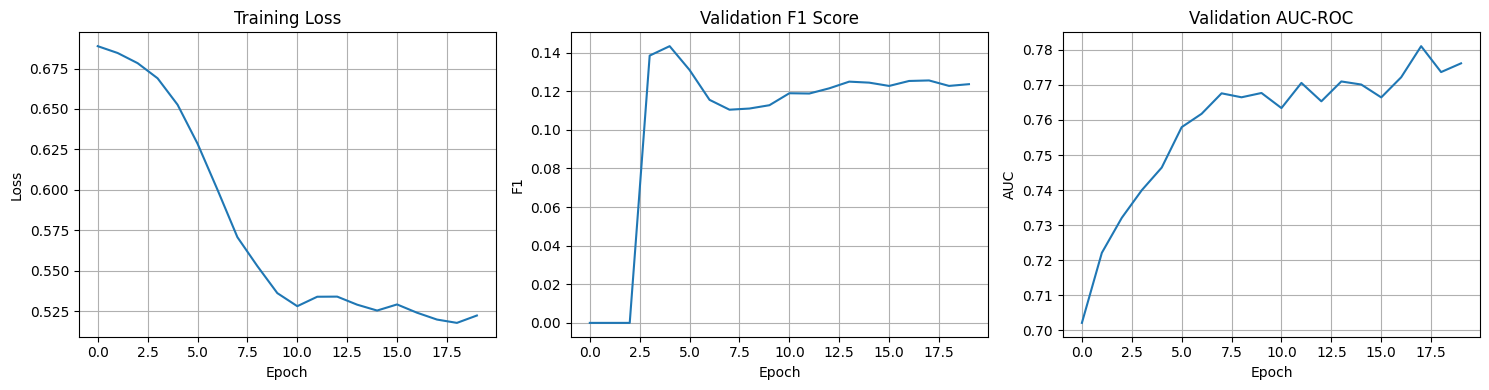

Best validation F1: 0.143
Best validation AUC: 0.781


In [26]:
# Visualize training progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['val_f1'])
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].grid(True)

axes[2].plot(history['val_auc'])
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation F1: {max(history['val_f1']):.3f}")
print(f"Best validation AUC: {max(history['val_auc']):.3f}")


In [ ]:
# ===== CELL: INTERACTIVE RISK HEATMAP WITH FOLIUM =====
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

print("Creating interactive risk heatmap...")

# Get node coordinates and risk predictions
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
all_nodes = list(G.nodes())

# Get risk predictions for all nodes (using test set as proxy)
# Create a mapping of predictions per node
node_risk_map = {}
for i, node_id in enumerate(nodes_test.cpu().numpy()):
    if node_id not in node_risk_map:
        node_risk_map[node_id] = []
    node_risk_map[node_id].append(test_prob[i])

# Average risk per node
node_risks = np.zeros(len(all_nodes))
for i, node_id in enumerate(all_nodes):
    if node_id in node_risk_map:
        node_risks[i] = np.mean(node_risk_map[node_id])

# Create base map centered on Manhattan
center_lat = node_coords[:, 0].mean()
center_lon = node_coords[:, 1].mean()

# Create heatmap layer
heatmap_data = [[node_coords[i][0], node_coords[i][1], node_risks[i]]
                for i in range(len(all_nodes))]

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

HeatMap(heatmap_data).add_to(m)

# Display map
# m

print(" Heatmap created (displayed in output)")
m

In [ ]:
# ===== CELL: FEATURE IMPORTANCE VISUALIZATION =====

# Get feature names
feature_names = ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
                 'hour', 'day_of_week', 'is_weekend', 'month',
                 'past_30d_crashes', 'days_since_last']

# Compute correlation of features with crash labels
feature_importance = []
for i, feat in enumerate(feature_names):
    if feat in train_balanced.columns:
        corr = np.abs(train_balanced[feat].corr(train_balanced['has_crash']))
        feature_importance.append(corr)
    else:
        feature_importance.append(0)

# Sort by importance
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_importance = [feature_importance[i] for i in sorted_indices]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#D7263D' if imp > 0.05 else '#2E86AB' for imp in sorted_importance]
bars = ax.barh(sorted_features, sorted_importance, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Absolute Correlation with Crash', fontsize=13, fontweight='bold')
ax.set_title('Feature Importance for Crash Prediction\n(Based on Correlation Analysis)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importance)):
    ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D7263D', edgecolor='black', label='High Importance (>0.05)'),
    Patch(facecolor='#2E86AB', edgecolor='black', label='Low Importance (≤0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Feature importance visualization saved")
print(f"\nTop 3 most important features:")
for i in range(min(3, len(sorted_features))):
    print(f"  {i+1}. {sorted_features[i]}: {sorted_importance[i]:.3f}")


In [ ]:
# ===== CELL: TEMPORAL PATTERNS VISUALIZATION =====

# Analyze crash patterns by hour and day of week
hourly_crashes = train_balanced.groupby('hour')['has_crash'].mean()
daily_crashes = train_balanced.groupby('day_of_week')['has_crash'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hour of day pattern
axes[0].bar(hourly_crashes.index, hourly_crashes.values * 100,
           color='#06A77D', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_title('Crash Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Add rush hour annotations
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Morning Rush')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
axes[0].legend()

# Day of week pattern
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(daily_crashes.index, daily_crashes.values * 100,
           color=['#2E86AB']*5 + ['#F77F00']*2,  # Weekdays blue, weekends orange
           edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Crash Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(day_names)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Temporal patterns visualization saved")


In [ ]:
# # Save predictions and important results
# print("Saving results...")

# # Save risk predictions
# risk_df.to_csv('nyc_risk_predictions.csv', index=False)
# print("Saved: nyc_risk_predictions.csv")

# # Save high-risk locations
# high_risk_nodes.to_csv('high_risk_locations.csv', index=False)
# print("Saved: high_risk_locations.csv")

# # Save model
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'num_features': data.num_node_features,
#     'test_metrics': {
#         'accuracy': test_acc,
#         'f1_score': test_f1,
#         'auc_roc': test_auc
#     }
# }, 'accident_prediction_model.pth')
# print("Saved: accident_prediction_model.pth")

# print("\n All results saved successfully!")
